In [33]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
import networkx as nx
from collections import defaultdict
import pandas as pd
from sentence_transformers import SentenceTransformer

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances

In [2]:
#model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [195]:
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [231]:
df = pd.read_pickle('df_with_normalized_units.pkl')
#df = df.reset_index(drop=True)
#df['story_id'] = df.index
df.drop(columns=['canonical_units','story_vec'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1503 non-null   int64 
 1   atu_id            1503 non-null   object
 2   tale_title        1503 non-null   object
 3   provenance        1489 non-null   object
 4   notes             821 non-null    object
 5   source            1325 non-null   object
 6   text              1503 non-null   object
 7   data_source       1503 non-null   object
 8   date_obtained     1503 non-null   object
 9   atu_number        1503 non-null   int64 
 10  extracted_units   1503 non-null   object
 11  story_id          1503 non-null   int64 
 12  normalized_units  1503 non-null   object
dtypes: int64(3), object(10)
memory usage: 152.8+ KB


In [232]:
df.to_pickle('df_ashliman_with_normalized_units.pkl')

In [22]:
df_yashpeh = pd.read_pickle('df_yashpeh_normaized_units_first500.pkl')
#df = df.reset_index(drop=True)
#df['story_id'] = df.index
df_yashpeh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        486 non-null    int64 
 1   tale_title        486 non-null    object
 2   book_name         485 non-null    object
 3   tradition         486 non-null    object
 4   url               486 non-null    object
 5   story_id          486 non-null    int64 
 6   text              486 non-null    object
 7   text_length       486 non-null    int64 
 8   extracted_units   486 non-null    object
 9   normalized_units  486 non-null    object
dtypes: int64(3), object(7)
memory usage: 38.1+ KB


In [23]:
new_df = df_yashpeh.copy()

if df.empty:
    next_id = 0
else:
    next_id = int(df['story_id'].max()) + 1

new_df["story_id"] = range(next_id, next_id + len(new_df))

for col in df.columns:
    if col not in new_df.columns:
        new_df[col] = pd.NA
new_df = new_df[df.columns]

df = pd.concat([df, new_df], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1989 non-null   int64 
 1   atu_id            1503 non-null   object
 2   tale_title        1989 non-null   object
 3   provenance        1489 non-null   object
 4   notes             821 non-null    object
 5   source            1325 non-null   object
 6   text              1989 non-null   object
 7   data_source       1503 non-null   object
 8   date_obtained     1503 non-null   object
 9   atu_number        1503 non-null   object
 10  extracted_units   1989 non-null   object
 11  story_id          1989 non-null   int64 
 12  normalized_units  1989 non-null   object
dtypes: int64(2), object(11)
memory usage: 202.1+ KB


In [196]:
all_units = []
all_story_ids = []

for _, row in df.iterrows():
    units = row["normalized_units"]
    sid = row["story_id"]
    for u in units:
        all_units.append(u)
        all_story_ids.append(int(sid))

len(all_units)

31184

In [197]:
model = model.to("cuda")

embeddings = model.encode(
    all_units,
    show_progress_bar=True,
    normalize_embeddings=True,
    batch_size=256,
    device="cuda"
)


Batches:   0%|          | 0/122 [00:00<?, ?it/s]

In [ ]:
"""
import numpy as np
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

def minibatch_agglomerative(
    embeddings,
    n_micro_clusters=1000,
    final_distance_threshold=0.6,
    linkage="average",
    metric="cosine",
    random_state=42,
    compute_silhouette=True
):

    print("Step 1: MiniBatchKMeans (micro-clusters)")
    mbk = MiniBatchKMeans(
        n_clusters=n_micro_clusters,
        batch_size=2048,
        random_state=random_state
    )
    micro_labels = mbk.fit_predict(embeddings)
    centroids = mbk.cluster_centers_

    print("Number of micro-clusters:", len(centroids))

    print("Step 2: Agglomerative on centroids")
    agg = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=final_distance_threshold,
        linkage=linkage,
        metric=metric
    )
    centroid_labels = agg.fit_predict(centroids)

    print("Final number of clusters:", len(np.unique(centroid_labels)))

    print("Step 3: Map back to original points")
    final_labels = centroid_labels[micro_labels]

    results = {
        "num_micro_clusters": n_micro_clusters,
        "num_final_clusters": len(np.unique(final_labels))
    }

    if compute_silhouette and len(np.unique(final_labels)) > 1:
        print("Computing silhouette (sampled)...")
        sample_size =len(embeddings)
        idx = np.random.choice(len(embeddings), sample_size, replace=False)
        sil = silhouette_score(
            embeddings[idx],
            final_labels[idx],
            metric=metric
        )
        results["silhouette"] = sil
        print("Silhouette:", sil)
    else:
        results["silhouette"] = None

    return final_labels, results


In [ ]:
"""
pca = PCA(n_components=200)
reduced_embeddings = pca.fit_transform(embeddings)

labels3, stats_mb = minibatch_agglomerative(
    reduced_embeddings,
    n_micro_clusters= 10000,
    final_distance_threshold=0.65
)

print(stats_mb)

Step 1: MiniBatchKMeans (micro-clusters)
Number of micro-clusters: 10000
Step 2: Agglomerative on centroids
Final number of clusters: 1828
Step 3: Map back to original points
Computing silhouette (sampled)...
Silhouette: 0.046593666
{'num_micro_clusters': 10000, 'num_final_clusters': 1828, 'silhouette': np.float32(0.046593666)}


In [ ]:
"""
pca = PCA(n_components=200)
reduced_embeddings = pca.fit_transform(embeddings)

labels3, stats_mb = minibatch_agglomerative(
    reduced_embeddings,      # PCA or UMAP reduced
    n_micro_clusters= 10000,   # try 800–2000
    final_distance_threshold=0.65
)

print(stats_mb)


Step 1: MiniBatchKMeans (micro-clusters)
Number of micro-clusters: 10000
Step 2: Agglomerative on centroids
Final number of clusters: 2587
Step 3: Map back to original points
Computing silhouette (sampled)...
Silhouette: 0.045767773
{'num_micro_clusters': 10000, 'num_final_clusters': 2587, 'silhouette': np.float32(0.045767773)}


In [ ]:
"""
from sklearn.cluster import Birch
pca = PCA(n_components=200)
reduced_embeddings = pca.fit_transform(embeddings)
#reduced_embeddings = embeddings
brc = Birch(threshold=0.6, branching_factor=500, n_clusters=None)
labels3 = brc.fit_predict(reduced_embeddings)

sil_score = silhouette_score(reduced_embeddings, labels3)

print(sil_score)

0.006990961


In [ ]:
import gc
gc.collect()

0

In [198]:
from sklearn.cluster import AgglomerativeClustering

#pca = PCA(n_components=200)
#reduced_embeddings = pca.fit_transform(embeddings)

svd = TruncatedSVD(n_components=200)
reduced_embeddings = svd.fit_transform(embeddings)

In [199]:

clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.6,
    metric="cosine",
    linkage="complete",
#    n_clusters=2000,
#    distance_threshold=None,
#    compute_full_tree=False

)

labels3 = clustering.fit_predict(reduced_embeddings)

sil_score = silhouette_score(reduced_embeddings, labels3)

print(sil_score)

0.07563731


In [200]:
from collections import defaultdict

clusters = defaultdict(list)

for idx, label in enumerate(labels3):
    if label != -1:
        clusters[label].append(idx)

cluster_sizes = {
    cluster_id: len(indices)
    for cluster_id, indices in clusters.items()
}


sorted_clusters = sorted(
    cluster_sizes.items(),
    key=lambda x: x[1],
    reverse=True
)

print(sorted_clusters[:10])



[(np.int64(30), 62), (np.int64(584), 58), (np.int64(146), 48), (np.int64(1133), 45), (np.int64(1403), 44), (np.int64(380), 40), (np.int64(1621), 39), (np.int64(336), 37), (np.int64(1707), 35), (np.int64(1325), 34)]


In [209]:
import numpy as np
from collections import defaultdict

labels = np.array(labels3)
story_ids = np.array(all_story_ids)

motif_clusters = []

for cluster_id, indices in clusters.items():
    unique_stories = set(story_ids[indices])
    if len(unique_stories) >= 2:
        motif_clusters.append(cluster_id)

print("Number of motif clusters:", len(motif_clusters))

all_stories = set(story_ids)

stories_with_motif = set()

for cluster_id in motif_clusters:
    indices = clusters[cluster_id]
    stories_with_motif.update(story_ids[indices])

stories_without_motif = all_stories - stories_with_motif

print("Number of stories without motif:", len(stories_without_motif))
print("Percentage:",
      len(stories_without_motif) / len(all_stories))


story_motif_count = defaultdict(set)

for cluster_id in motif_clusters:
    for idx in clusters[cluster_id]:
        story = story_ids[idx]
        story_motif_count[story].add(cluster_id)

motifs_per_story = [len(v) for v in story_motif_count.values()]

print("Average motifs per story:", np.mean(motifs_per_story))



Number of motif clusters: 4725
Number of stories without motif: 7
Percentage: 0.003519356460532931
Average motifs per story: 9.010090817356206


In [202]:
def compute_cluster_entropy(embeddings, cluster_labels):

    global_mean = embeddings.mean(axis=0)
    global_var = np.mean(np.sum((embeddings - global_mean) ** 2, axis=1))

    entropies = []

    for cid in np.unique(cluster_labels):
        idx = np.where(cluster_labels == cid)[0]
        cluster_embs = embeddings[idx]

        if len(cluster_embs) <= 1:
            continue

        cluster_mean = cluster_embs.mean(axis=0)
        cluster_var = np.mean(
            np.sum((cluster_embs - cluster_mean) ** 2, axis=1)
        )

        entropies.append(cluster_var / global_var)

    return float(np.mean(entropies)) if entropies else 0.0

def between_cluster_distances(embeddings, cluster_labels, type= 'mean'):
    labels = np.asarray(cluster_labels)
    unique_labels = np.unique(labels)

    centroids = []
    for cid in unique_labels:
        centroids.append(embeddings[labels == cid].mean(axis=0))

    centroids = np.vstack(centroids)

    dist_matrix = cosine_distances(centroids)
    iu = np.triu_indices_from(dist_matrix, k=1)
    distances = dist_matrix[iu]
    if type == 'mean':
        return distances.mean()
    elif type == 'max':
        return distances.max()
    elif type == 'min':
        return distances.min()
    else:
       return distances.mean()


In [203]:
N = len(all_units)
cluster_labels = labels3
K = len(np.unique(cluster_labels))

compression_ratio = N / K
cluster_entropy = compute_cluster_entropy(
            reduced_embeddings, cluster_labels
        )

between_cluster = between_cluster_distances(
            reduced_embeddings, cluster_labels, type = 'mean'
        )

print(f"compression_ration: {compression_ratio}")
print(f"cluster_entropy: {cluster_entropy}")
print(f"between_cluster: {between_cluster}")

compression_ration: 4.883946750195771
cluster_entropy: 0.33816513419151306
between_cluster: 0.8139197826385498


In [204]:
def cluster_story_distribution(unit_to_clust):
    rows = []

    for cid, g in unit_to_clust.groupby("cluster_label"):
        story_counts = g["story_id"].value_counts()
        n = story_counts.sum() # n is total number of nuites in this cluster
        m = story_counts.shape[0] # m is the number of unique story IDs of units in this cluster


        p = story_counts.values / n

        entropy = -np.sum(p * np.log(p))
        norm_entropy = entropy / np.log(m) if m > 1 else 0.0

        rows.append({
            "cluster_label": cid,
            "cluster_size": n,
            "story_support": m,
            "story_entropy": entropy,
            "story_entropy_norm": norm_entropy,
            "coverage_ratio": m / n
        })

    return pd.DataFrame(rows)

In [205]:

from collections import defaultdict

cluster_to_indices = defaultdict(list)
for i, cid in enumerate(cluster_labels):
    cluster_to_indices[cid].append(i)

def get_cluster_representative(indices):
    embs = reduced_embeddings[indices]
    centroid = embs.mean(axis=0, keepdims=True)
    sims = cosine_similarity(embs, centroid).ravel()
    return all_units[indices[np.argmax(sims)]]

unit_to_clust = pd.DataFrame({
    "unit": all_units,
    "cluster_label": cluster_labels,
    "story_id": all_story_ids
})


clusters_info = []
for cid, indices in cluster_to_indices.items():
    embs = reduced_embeddings[indices]

    clusters_info.append({
        "cluster_label": cid,
        "cluster_mean_embedding": embs.mean(axis=0),
        "cluster_representative": get_cluster_representative(indices),
        "cluster_size": len(indices)
    })

clusters_info = pd.DataFrame(clusters_info)
clusters_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6385 entries, 0 to 6384
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   cluster_label           6385 non-null   int64 
 1   cluster_mean_embedding  6385 non-null   object
 2   cluster_representative  6385 non-null   object
 3   cluster_size            6385 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 199.7+ KB


In [210]:
motif_clusters = clusters_info.merge(
    cluster_story_distribution(unit_to_clust),
    on="cluster_label"
)

motif_clusters = motif_clusters[
    motif_clusters["story_support"] >= 2
]
motif_clusters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4725 entries, 0 to 6354
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cluster_label           4725 non-null   int64  
 1   cluster_mean_embedding  4725 non-null   object 
 2   cluster_representative  4725 non-null   object 
 3   cluster_size_x          4725 non-null   int64  
 4   cluster_size_y          4725 non-null   int64  
 5   story_support           4725 non-null   int64  
 6   story_entropy           4725 non-null   float64
 7   story_entropy_norm      4725 non-null   float64
 8   coverage_ratio          4725 non-null   float64
dtypes: float64(3), int64(4), object(2)
memory usage: 369.1+ KB


In [211]:
units_to_embed = dict(zip(all_units, reduced_embeddings))

In [212]:
unit_to_cluster = dict(zip(unit_to_clust["unit"], unit_to_clust["cluster_label"]))
motif_cluster_to_centroid = dict(
    zip(motif_clusters["cluster_label"], motif_clusters["cluster_mean_embedding"])
)

def units_to_centroids_with_fallback(units):
    centroids = []
    seen_clusters = set()
    for u in units:
        cid = unit_to_cluster.get(u, None)
        if cid is None or cid in seen_clusters:
            continue
        seen_clusters.add(cid)
        centroid = motif_cluster_to_centroid.get(cid, None)
        if centroid is not None:
            centroids.append(centroid)
    if not centroids:  # fallback
        embeddings = [units_to_embed[u] for u in units if u in units_to_embed]
        if embeddings:
            centroids.append(np.mean(embeddings, axis=0))
    return centroids

df["canonical_units"] = df["normalized_units"].apply(units_to_centroids_with_fallback)


# Cross reference with TMI

In [216]:
import pandas as pd
import torch
from sentence_transformers import util

def compare_with_thompson(df, atu_to_tmi, model, reducer, level="thompson_motif_text", sim_thr=0.4):

    reference_per_atu = (
        atu_to_tmi
        .groupby('atu_id')
        .agg({
            level: list,
            'thompson_motif_id': list
        })
        .rename(columns={
            level: 'ref_texts',
            'thompson_motif_id': 'ref_ids'
        })
    )

    all_ref_texts = []
    atu_offsets = {}
    offset = 0

    for atu, row in reference_per_atu.iterrows():
        texts = row['ref_texts']
        if texts:
            all_ref_texts.extend(texts)
            atu_offsets[atu] = (offset, offset + len(texts))
            offset += len(texts)

    if not all_ref_texts:
        return pd.DataFrame()

    ref_embeddings_full = model.encode(
        all_ref_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=128,
        device = "cuda"
    )
    if reducer is not None:
        ref_embeddings_reduced = reducer.transform(ref_embeddings_full)
    else:
        ref_embeddings_reduced = ref_embeddings_full

    ref_embeddings = {}
    for atu, (start, end) in atu_offsets.items():
        ref_embeddings[atu] = ref_embeddings_reduced[start:end]

    def flatten_vectors(list_of_lists):
        return [vec for sublist in list_of_lists if isinstance(sublist, list) for vec in sublist]

    df_grouped = (
        df.groupby("atu_id")["canonical_units"]
        .agg(flatten_vectors)
        .reset_index()
        .rename(columns={"canonical_units": "aggregated_canonical"})
    )

    comparison_df = df_grouped.merge(
        reference_per_atu.reset_index(),
        on='atu_id',
        how='inner'
    )

    results = []

    for _, row in comparison_df.iterrows():
        atu = row['atu_id']
        canon_vecs = row['aggregated_canonical']

        if canon_vecs is None or len(canon_vecs) == 0:
            results.append({
                'atu_id': atu,
                'n_stories': 0,
                'n_your_motifs': 0,
                'n_ref_motifs': len(row['ref_texts']),
                'recall': 0.0,
                'precision': 0.0
            })
            continue

        emb_yours = torch.tensor(canon_vecs, dtype=torch.float32)
        emb_ref = torch.tensor(ref_embeddings.get(atu, []), dtype=torch.float32)

        if emb_ref.numel() == 0:
            continue

        emb_yours = torch.nn.functional.normalize(emb_yours, p=2, dim=1)
        emb_ref = torch.nn.functional.normalize(emb_ref, p=2, dim=1)

        sim_matrix = util.cos_sim(emb_yours, emb_ref)

        max_per_ref = sim_matrix.max(dim=0).values
        recall = (max_per_ref >= sim_thr).float().mean().item()

        max_per_yours = sim_matrix.max(dim=1).values
        precision = (max_per_yours >= sim_thr).float().mean().item()

        results.append({
            'atu_id': atu,
            'n_stories': len(df[df['atu_id'] == atu]),
            'n_your_motifs': len(canon_vecs),
            'n_ref_motifs': len(row['ref_texts']),
            'recall': round(recall, 3),
            'precision': round(precision, 3)
        })

    results_df = pd.DataFrame(results)

    return results_df


In [98]:
atu_to_tmi = pd.read_csv("ATU_to_TMI.csv")
atu_to_tmi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2161 entries, 0 to 2160
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0.1             2161 non-null   int64 
 1   Unnamed: 0               2161 non-null   int64 
 2   ATU Classification Type  2161 non-null   object
 3   Thompson Motif           2161 non-null   object
 4   atu_id                   2161 non-null   object
 5   thompson_motif_id        2161 non-null   object
 6   thompson_motif_text      2161 non-null   object
 7   chapter                  2161 non-null   object
 8   division1                2155 non-null   object
 9   division2                1218 non-null   object
 10  division3                240 non-null    object
 11  section_tens             2161 non-null   object
 12  MOTIF                    2161 non-null   object
 13  chapter_text             2161 non-null   object
 14  division1_text           2155 non-null  

In [217]:
results_df = compare_with_thompson(
    df,
    atu_to_tmi,
    model,
    reducer=svd,
    sim_thr=0.4
)

print(results_df.head())
print(results_df[['recall','precision']].mean())


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

  atu_id  n_stories  n_your_motifs  n_ref_motifs  recall  precision
0      1          8             70             1     1.0      0.086
1    101          5             45             1     1.0      0.089
2    103          2             24             1     1.0      0.125
3   1030         11             71             1     1.0      0.437
4    105         13             89             1     1.0      0.169
recall       0.826677
precision    0.281584
dtype: float64


# Cross-Story Evaluation

In [218]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
from collections import defaultdict

column_name = 'normalized_units'
df_units = df.explode(column_name).reset_index(drop=True)
df_units = df_units.rename(columns={column_name : "unit"})

model = model.to("cuda")

all_embeddings = model.encode(
    df_units["unit"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
    batch_size=256,
    device="cuda"
)

df_units["embedding_index"] = np.arange(len(df_units))


Batches:   0%|          | 0/122 [00:00<?, ?it/s]

In [219]:

atu_counts = df.groupby("atu_id", dropna=True)["story_id"].nunique()

# Keep only ATUs with at least 2 stories
valid_atus = atu_counts[atu_counts >= 2].index

#
df_non_nan = df[
    df["atu_id"].notna() & df["atu_id"].isin(valid_atus)
].copy()


df_nan = df[df["atu_id"].isna()].copy()


unique_stories_non_nan = df_non_nan["story_id"].unique()
atu_per_story = df_non_nan.groupby("story_id")["atu_id"].first()

train_stories_non_nan, test_stories = train_test_split(
    unique_stories_non_nan,
    test_size=0.2,
    random_state=42,
    stratify=atu_per_story.loc[unique_stories_non_nan]
)


nan_stories = df_nan["story_id"].unique()
print(f"number of stories from Yashpeh dataset : {len(nan_stories)}")
train_stories = list(train_stories_non_nan) + list(nan_stories)


train_mask = df_units["story_id"].isin(train_stories)
test_mask  = df_units["story_id"].isin(test_stories)

train_units = df_units[train_mask]
test_units  = df_units[test_mask]

number of stories from Yashpeh dataset : 486


In [220]:

train_embeddings = all_embeddings[train_units["embedding_index"].values]

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=200)
train_reduced = svd.fit_transform(train_embeddings)

clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.6,
    metric="cosine",
    linkage="complete"
)
train_cluster_labels = clustering.fit_predict(train_reduced)

print("clustering finishes")

train_df = train_units.copy()
train_df["cluster_label"] = train_cluster_labels
train_df["row_id"] = np.arange(len(train_reduced))


valid_clusters = (
    train_df.groupby("cluster_label")["story_id"]
    .nunique()
)
valid_clusters = valid_clusters[valid_clusters >= 2].index.tolist()

train_df = train_df[train_df["cluster_label"].isin(valid_clusters)].copy()

cluster_centroids = {}

for cid in valid_clusters:
    rows = train_df[train_df["cluster_label"] == cid]["row_id"].values
    cluster_centroids[cid] = train_reduced[rows].mean(axis=0)


centroid_matrix = np.vstack(list(cluster_centroids.values()))
centroid_ids = list(cluster_centroids.keys())
test_embeddings = all_embeddings[test_units["embedding_index"].values]
test_reduced = svd.transform(test_embeddings)


# Assign clusters
sim_matrix = cosine_similarity(test_reduced, centroid_matrix)
assigned_clusters = [centroid_ids[i] for i in sim_matrix.argmax(axis=1)]
test_units = test_units.copy()
test_units["cluster_label"] = assigned_clusters


clustering finishes


In [221]:
def aggregate_story_vectors(df_part):
    return (
        df_part
        .groupby("story_id")["cluster_label"]
        .apply(lambda x: list(set(x)))
        .reset_index()
    )

train_story_clusters = aggregate_story_vectors(train_df)
test_story_clusters  = aggregate_story_vectors(test_units)


In [222]:
train_story_clusters = train_story_clusters.merge(
    df[["story_id", "atu_id"]],
    on="story_id"
)

atu_prototypes = {}

for atu, group in train_story_clusters.groupby("atu_id"):
    cluster_ids = [c for clusters in group["cluster_label"] for c in clusters]
    unique_clusters = list(set(cluster_ids))
    vectors = [cluster_centroids[c] for c in unique_clusters if c in cluster_centroids]
    atu_prototypes[atu] = np.mean(vectors, axis=0)


In [223]:
test_story_clusters = test_story_clusters.merge(
    df[["story_id", "atu_id"]],
    on="story_id"
)

predictions = []
true_labels = []

for _, row in test_story_clusters.iterrows():
    clusters = row["cluster_label"]
    story_vectors = [cluster_centroids[c] for c in clusters if c in cluster_centroids]

    if not story_vectors:
        continue

    story_vector = np.mean(story_vectors, axis=0)

    best_atu = None
    best_sim = -1

    for atu, proto in atu_prototypes.items():
        sim = cosine_similarity([story_vector], [proto])[0][0]
        if sim > best_sim:
            best_sim = sim
            best_atu = atu

    predictions.append(best_atu)
    true_labels.append(row["atu_id"])


In [224]:
accuracy = accuracy_score(true_labels, predictions)
print("Cross-Story Generalization Accuracy:", round(accuracy, 4))


Cross-Story Generalization Accuracy: 0.4482


# Some Analysis

In [100]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage

,cluster_label,cluster_mean_embedding,cluster_representative,cluster_size_x,cluster_size_y,story_support,story_entropy,story_entropy_norm,coverage_ratio
172,21,"[-0.4093923, -0.30561367, 0.17470677, 0.053908...",The rabbit pretends to fall for the trick but ...,32,32,12,2.324837,0.935583,0.375


In [49]:
unit_to_clust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31184 entries, 0 to 31183
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   unit           31184 non-null  object
 1   cluster_label  31184 non-null  int64 
 2   story_id       31184 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 731.0+ KB


In [226]:
result = (
    unit_to_clust.groupby('cluster_label')['story_id']
      .nunique()
      .sort_values(ascending=False)
      .rename('n_unique_stories')
)

print("Clusters sorted by number of different story_ids (highest first):")
print(result[80:90])

Clusters sorted by number of different story_ids (highest first):
cluster_label
3168    11
1058    11
1057    11
215     11
1083    11
2421    11
375     11
423     11
381     11
116     11
Name: n_unique_stories, dtype: int64


In [227]:
motif_clusters[motif_clusters['cluster_label']==116]['cluster_representative']

,cluster_representative
2607,The child gets sick and dies


In [194]:
unit_to_clust[unit_to_clust['cluster_label']==1061]['unit'].tolist()

["The king 's wives send for the prince to reveal their plan to him .",
 'A king grants permission to summon his princess to go in marriage .',
 "Ambassadors from another city come to summon the king 's princess to get married .",
 'The mouseling becomes the princess again , and she gets married to the prince .',
 'The youngest princess agrees to marry the man , while the others refuse .',
 'The man sends his picture to the king , which causes a reaction from the princess .',
 'The king is bound by his promise to marry the man off to the youngest princess .',
 "The man arrives at the king 's palace in his new , clean state , and marries the youngest princess .",
 'A hidden prince is revealed , having been enchanted , and a romance develops .',
 'The old man demands that the king give him one of his daughters , which turns out to be the youngest princess .',
 "The princess is taken back to the old man 's castle to fulfill her promise .",
 "The princess is unable to resist her sister 's 

In [76]:
clusters_info[clusters_info['cluster_label']==1391]['cluster_representative'][1300]

"The king 's son takes the daughter to the palace as his potential bride ."

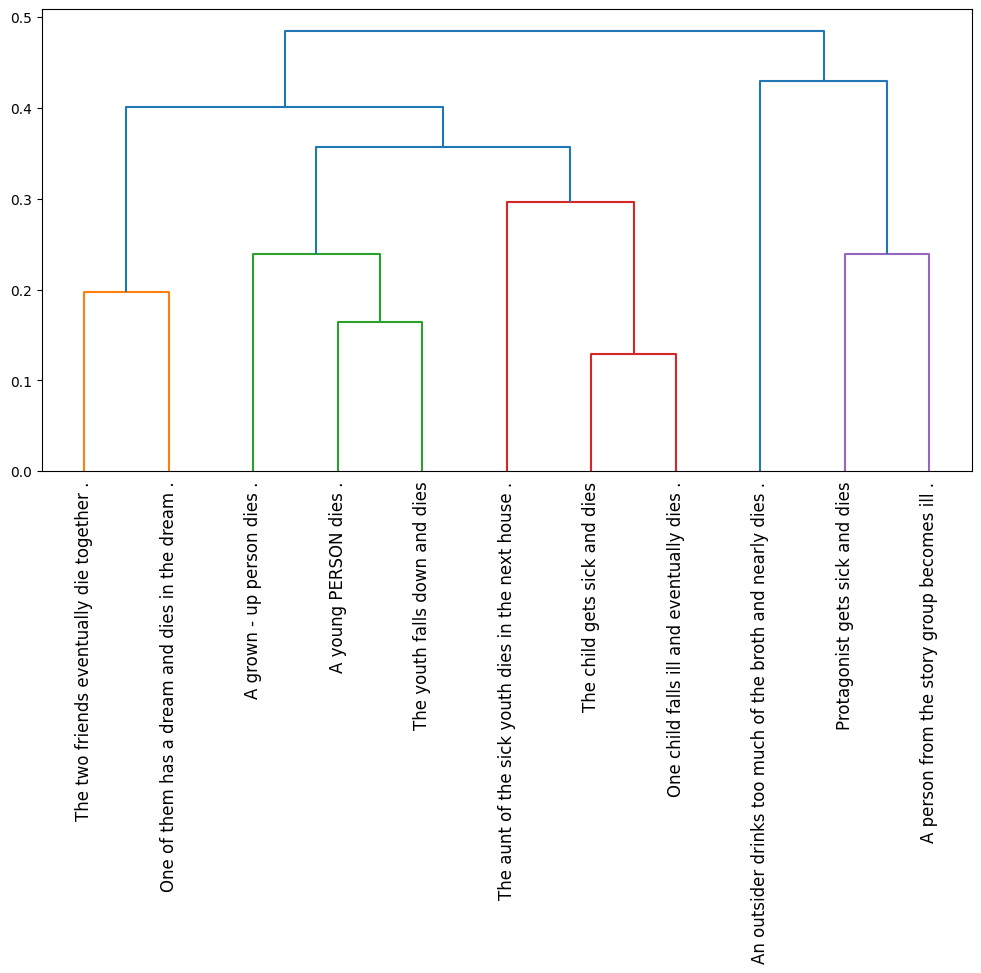

In [228]:

cluster_id = 116
cluster_indices = [i for i, l in enumerate(cluster_labels) if l == cluster_id]
Z_sub = linkage(reduced_embeddings[cluster_indices], method="average", metric="cosine")

plt.figure(figsize=(12, 6))
dendrogram(Z_sub, labels=[all_units[i] for i in cluster_indices])
plt.xticks(rotation=90)
plt.show()

In [229]:
unit_to_clust.to_csv('units_to_clusters.csv')


In [230]:
clusters_info.to_csv('clusters_details.csv')